## Brownian motion to smooth time series curve

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import beta, norm, kstest
from sklearn.metrics import mean_squared_error
import warnings
from scipy.interpolate import make_splrep
import random

In [2]:
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv('../../data/processed/dataset_clean_no-outliers.csv').drop(columns=['Unnamed: 0.1', 'Unnamed: 0'])

In [4]:
df18 = pd.read_csv('../../data/processed/dataset_2018-21_clean.csv').drop(columns='Unnamed: 0')

In [5]:
speed = df['speed'][6:].reset_index(drop=True)
power = df['power'][:-6].reset_index(drop=True)

In [6]:
beta.ppf(0.51, 1e-3, 1e-3, loc=0, scale=1)

0.9999999983197947

In [7]:
normalized_power = (power - power.min()) / (power.max() - power.min())

epsilon = 1e-15
normalized_power = np.clip(normalized_power, epsilon, 1 - epsilon)

In [8]:
normalized_power.describe()

count    4.380300e+04
mean     4.271202e-01
std      2.559938e-01
min      1.000000e-15
25%      1.990966e-01
50%      4.132976e-01
75%      6.491649e-01
max      1.000000e+00
Name: power, dtype: float64

In [9]:
def fit_params_spline(speed, power, intervals, k, s):
    params = pd.DataFrame(columns=['avg_speed', 'a', 'b', 'loc', 'scale'])
    num_intervals = len(intervals) - 1

    for i in range(num_intervals):
        lower = intervals[i]
        upper = intervals[i+1]
        avg_speed = (lower + upper) / 2
        filtered_power = power[(speed >= lower) & (speed < upper)]
        params.loc[len(params)] = [avg_speed] + list(beta.fit(filtered_power, floc=0, fscale=1))

    # a_spline = UnivariateSpline(params['avg_speed'], params['a'], k=k, s=s)
    # b_spline = UnivariateSpline(params['avg_speed'], params['b'], k=k, s=s)
    a_spline = make_splrep(np.array(params['avg_speed']), np.array(params['a']), k=k, s=s)
    b_spline = make_splrep(np.array(params['avg_speed']), np.array(params['b']), k=k, s=s)

    return a_spline, b_spline

In [11]:
lowers = np.array([ 0. ,  0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,
         5.5,  6. ,  6.5,  7. ,  7.5,  8. ,  8.5,  9. ,  9.5, 10. , 10.5,
        11. , 11.5, 12. , 12.5, 13. , 13.5, 14. , 14.5, 15. , 15.5, 16. ,
        16.5])
uppers = np.array([ 0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,  5.5,
         6. ,  6.5,  7. ,  7.5,  8. ,  8.5,  9. ,  9.5, 10. , 10.5, 11. ,
        11.5, 12. , 12.5, 13. , 13.5, 14. , 14.5, 15. , 15.5, 16. , 16.5,
        20. ])

In [12]:
lowers = np.array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17])
uppers = np.array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        20])

In [10]:
def fit(speeds, power, lowers, uppers, k, s):
    #power = self.normalize_power(power)

    params = pd.DataFrame(columns=['avg_speed', 'a', 'b', 'loc', 'scale'])
    num_intervals = len(lowers)

    for i in range(num_intervals):
        lower = lowers[i]
        upper = uppers[i]
        avg_speed = (lower + upper) / 2
        filtered_power = power[(speeds >= lower) & (speeds < upper)]
        params.loc[len(params)] = [avg_speed] + list(beta.fit(filtered_power, floc=0, fscale=1))

    a_spline = make_splrep(np.array(params['avg_speed']), np.array(params['a']), k=k, s=s)
    b_spline = make_splrep(np.array(params['avg_speed']), np.array(params['b']), k=k, s=s)

    return a_spline, b_spline

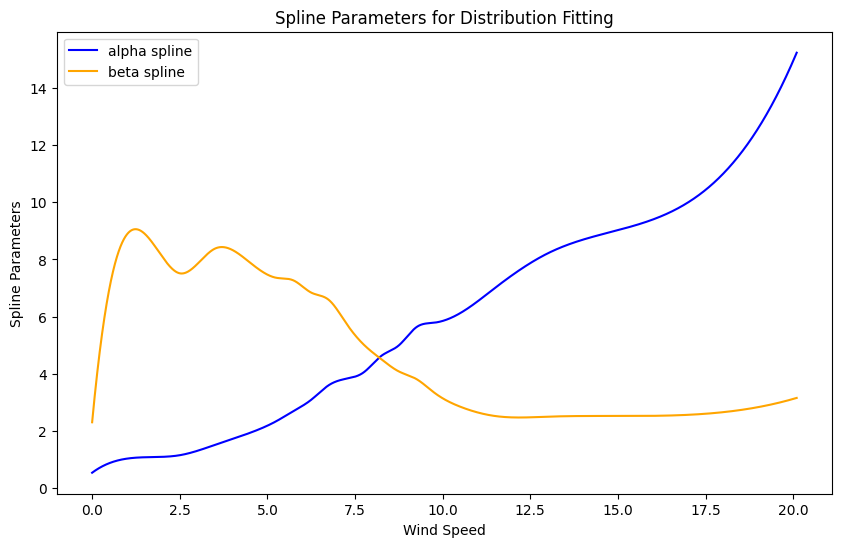

In [14]:
intervals = [0, 1, 2, 3, 4, 5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10, 11, 12, 14, 17, 20]
k = 3
s = 0
# a_spline, b_spline = fit(speed, normalized_power, lowers, uppers, k=k, s=s)
a_spline, b_spline = fit_params_spline(speed, normalized_power, intervals, k=k, s=s)

x = np.linspace(0, 20.1, 10000)
y_a = a_spline(x)
y_b = b_spline(x)
plt.figure(figsize=(10, 6))
plt.plot(x, y_a, label='alpha spline', color='blue')
plt.plot(x, y_b, label='beta spline', color='orange')
# plt.scatter(intervals[:-1], [a_spline(i) for i in intervals[:-1]], color='blue', marker='o', label='a_spline points')
# plt.scatter(intervals[:-1], [b_spline(i) for i in intervals[:-1]], color='orange', marker='o', label='b_spline points')
plt.title('Spline Parameters for Distribution Fitting')
plt.xlabel('Wind Speed')
plt.ylabel('Spline Parameters')
plt.legend()

In [15]:
a_spline(20)

array(14.94694177)

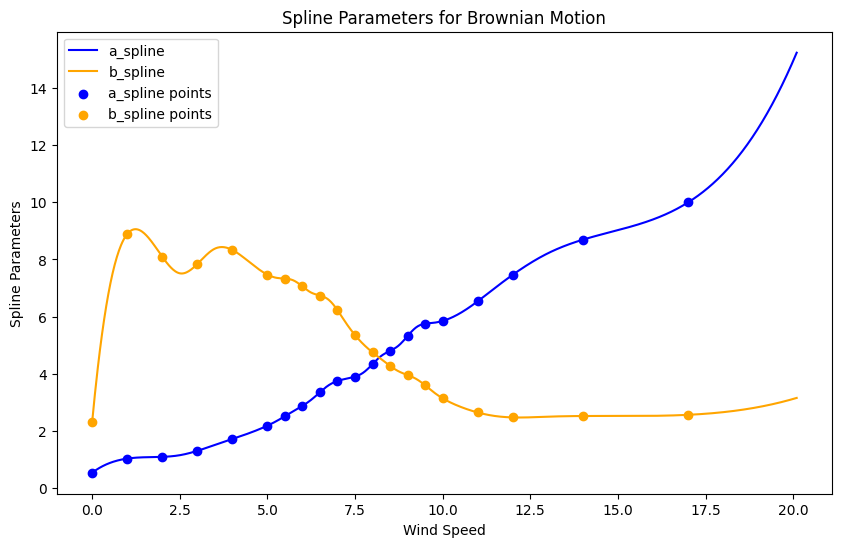

In [16]:
x = np.linspace(0, 20.1, 1000)
y_a = a_spline(x)
y_b = b_spline(x)
plt.figure(figsize=(10, 6))
plt.plot(x, y_a, label='a_spline', color='blue')
plt.plot(x, y_b, label='b_spline', color='orange')
plt.scatter(intervals[:-1], [a_spline(i) for i in intervals[:-1]], color='blue', marker='o', label='a_spline points')
plt.scatter(intervals[:-1], [b_spline(i) for i in intervals[:-1]], color='orange', marker='o', label='b_spline points')
plt.title('Spline Parameters for Brownian Motion')
plt.xlabel('Wind Speed')
plt.ylabel('Spline Parameters')
plt.legend()

In [11]:
def get_all_distributions(df, intervals):
    fitted_distributions = {}
    num_intervals = len(intervals) - 1

    for i in range(num_intervals):
        lower = intervals[i]
        upper = intervals[i+1]
        power = df[(df['speed'] >= lower) & (df['speed'] < upper)]['power']

        params = beta.fit(power, floc=0, fscale=20000)
        p = kstest(power, 'beta', args=params)[1]

        fitted_distributions[f'{lower}-{upper}'] = {
            'params': params,
            'p_value': p
        }
        
    return fitted_distributions

In [12]:
# splines, but without brownian motion
def pred_power(speeds, a_spline, b_spline):
    pred_powers = []
    for speed in speeds:
        a = a_spline(speed)
        b = b_spline(speed)
        pred_power = beta.rvs(a, b, loc=0, scale=20000)
        pred_powers.append(pred_power)
    return np.array(pred_powers)

In [13]:
# brownian motion without splines
def pred_power(speeds, fitted_distributions, intervals, smoothing_factor, drift_factor):
    predictions = []
    prev_w = None # w is the inverse CDF input to get the sampled power

    for speed in speeds:
        for i in range(len(intervals) - 1):
            lower = intervals[i]
            upper = intervals[i + 1]
            if lower <= speed < upper:
                params = fitted_distributions[f'{lower}-{upper}']['params']

                if prev_w is None:
                    w = np.random.rand(1)[0]
                else:
                    # use previous w to smooth the current w; brownian motion
                    smoothing_condition = smoothing_factor * norm.rvs(0, 1, size=1)[0]
                    drift_condition = drift_factor * (0.5 - prev_w) # drift towards median 0.5
                    w = prev_w + smoothing_condition + drift_condition
                    # ensure w stays within [0, 1]
                    w = max(0, min(w, 1))
                
                prev_w = w
                sample = beta.ppf(w, *params)

                # avoid sampling out of the range 0 to 20000
                #sampled_power = max(0, min(sampled_power, 20000))

                predictions.append(sample)
                break
    return predictions

In [14]:
# brownian motion with splines
def pred_power(speeds, a_spline, b_spline, smoothing_factor=0.01, drift_factor=0.001, reset_prev_w=0.02):
    predictions = []
    prev_w = None  # w is the inverse CDF input to get the sampled power
    reset_counter = 0

    for speed in speeds:
        a = a_spline(speed)
        b = b_spline(speed)

        if prev_w is None or random.random() < reset_prev_w:
            w = np.random.rand(1)[0]
            reset_counter += 1
        else:
            # use previous w to smooth the current w; brownian motion
            smoothing_condition = norm.rvs(0, 1, size=1)[0] * smoothing_factor
            drift_condition = drift_factor * (0.5 - prev_w) # drift towards median 0.5
            w = prev_w + smoothing_condition + drift_condition
            # ensure w stays within [0, 1]
            if w < 0: w = -w
            if w > 1: w = 2-w

        prev_w = w
        pred = beta.ppf(w, a, b, loc=0, scale=1)
        predictions.append(pred)
    
    print(f"Reset counter: {reset_counter}")

    return predictions

In [21]:
# old; brownian motion without splines
intervals = [0, 1, 2, 3, 4, 5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10, 11, 12, 14, 17, 20.1]
fitted = get_all_distributions(df, intervals)
preds = pred_power(df['speed'], fitted, intervals, smoothing_factor=0.01)
df['predicted_power'] = preds

TypeError: 'dict' object is not callable

In [22]:
speed = df18['speed_HRRR']
power = df18['power_cf']

In [23]:
normalized_power = (power - power.min()) / (power.max() - power.min())

epsilon = 1e-15
normalized_power = np.clip(normalized_power, epsilon, 1 - epsilon)

In [15]:
# brownian motion with splines
intervals = [0, 1, 2, 3, 4, 5, 5.5, 6, 6.5, 7, 7.5, 8, 8.5, 9, 9.5, 10, 11, 12, 14, 17, 20]
a_spline, b_spline = fit_params_spline(speed, normalized_power, intervals, 3, 0)
preds = pred_power(speed, a_spline, b_spline, smoothing_factor=0.01, drift_factor=0.001)
df_pred = pd.DataFrame({'speed': speed, 'power': normalized_power, 'predicted_power_spline_brownian': preds})

Reset counter: 836


Text(0, 0.5, 'Power (Normalized)')

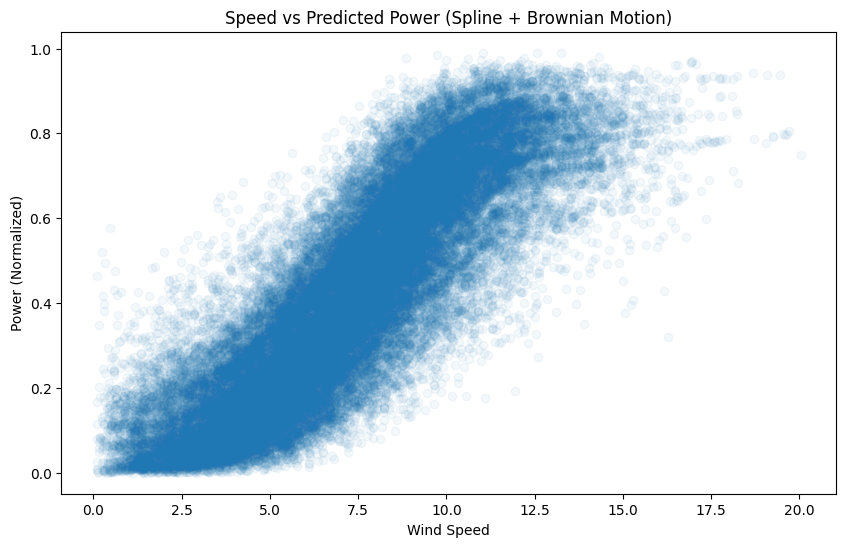

In [49]:
plt.figure(figsize=(10, 6))
plt.scatter(df_pred['speed'], df_pred['predicted_power_spline_brownian'], alpha=0.05)
plt.title('Speed vs Predicted Power (Spline + Brownian Motion)')
plt.xlabel('Wind Speed')
plt.ylabel('Power (Normalized)')

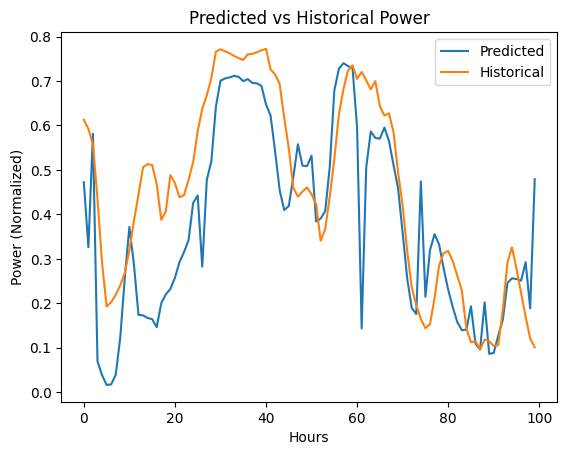

In [16]:
plt.plot(df_pred['predicted_power_spline_brownian'][20000:20100].reset_index(drop=True), label='Predicted')
plt.plot(df_pred['power'][20000:20100].reset_index(drop=True), label='Historical')
plt.xlabel('Hours')
plt.ylabel('Power (Normalized)')
plt.title('Predicted vs Historical Power')
plt.legend()

In [20]:
mean_squared_error(df_pred['power'], df_pred['predicted_power_spline_brownian'])

0.03562542119018114

In [18]:
plt.figure(figsize=(10, 6))
plt.scatter(df['speed'], df['predicted_power'], alpha=0.05)
plt.title('Speed vs Predicted Power 2020-2024')
plt.xlabel('Wind Speed')
plt.ylabel('Power Output')

KeyError: 'predicted_power'

<Figure size 1000x600 with 0 Axes>

In [19]:
plt.plot(df['predicted_power'][6:174].reset_index(drop=True), label='Predicted')
plt.plot(df['power'][0:168].reset_index(drop=True), label='Historical')
plt.xlabel('Hours')
plt.ylabel('Power Output')
plt.title('Predicted vs Historical Power Output for One Week')
plt.legend()

KeyError: 'predicted_power'